In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:


models = [ "aug_cnn_4l_short",
        "aug_cnn_4l_short_input_edt",
        "aug_cnn_4l_short_input_edt_vein",
    "aug_cnn_4l_short_input_edt_fp_fix",

           "aug_cnn_4l_short_input_edt_fp_strict_fix",
             "zaug_cnn_4l_short_input_edt", "zaug_cnn_4l_short_input_edt_vein", "yaug_cnn_4l_short_input_edt",  "xaug_cnn_4l_short_input_edt", ]


datasets = ["cmha", "hospital140", "internal_test"]


path_results_template = "../results/{dataset}/{model}/iou{iou_threshold}_froc_{chkpt}/froc.csv"

iou_threshold = 0.2 

values = [1, 3, 5] # 0.1, 0.5, 2
val_labels = ["Se@0.1", "Se@0.5", "Se@2"]

#chkpts = ["10k", "13k", "16k", "final"]
chkpts = ["final"]
columns = ["model", "dataset", "checkpoint"] + val_labels
rows = []
for dataset in datasets:
    for model in models:
        for chkpt in chkpts:
            path_results = path_results_template.format(dataset=dataset, model=model, iou_threshold=iou_threshold, chkpt=chkpt)
            try:
                df = pd.read_csv(path_results)
            except Exception as e:
                print(f"Could not read {path_results}: {e}")
                continue
            # print(f"Model: {model}, Dataset: {dataset}, Checkpoint: {chkpt}")
            row = [dataset, model, chkpt]
            for val in values:
                se = df.iloc[0,val]
                row.append(se)
            rows.append(row)

df = pd.DataFrame(columns=columns, data=rows)


In [74]:
df

,model,dataset,checkpoint,Se@0.1,Se@0.5,Se@2
0,cmha,aug_cnn_4l_short,final,0.520,0.790,0.840
1,cmha,aug_cnn_4l_short_input_edt,final,0.690,0.880,0.920
2,cmha,aug_cnn_4l_short_input_edt_vein,final,0.690,0.850,0.910
3,cmha,aug_cnn_4l_short_input_edt_fp_fix,final,0.710,0.920,0.940
4,cmha,aug_cnn_4l_short_input_edt_fp_strict_fix,final,0.580,0.930,0.950
5,cmha,zaug_cnn_4l_short_input_edt,final,0.640,0.830,0.890
6,cmha,zaug_cnn_4l_short_input_edt_vein,final,0.690,0.870,0.920
7,cmha,yaug_cnn_4l_short_input_edt,final,0.600,0.860,0.900
8,cmha,xaug_cnn_4l_short_input_edt,final,0.600,0.810,0.870
9,hospital140,aug_cnn_4l_short,final,0.396,0.590,0.750


In [51]:
train_data_path = "/projects/vig/alberto/medical/deform-aneurysm-detection/labels/gt/internal_train_crop_0.4_confirmed_fps_fix.csv"

df_train = pd.read_csv(train_data_path)
df_train = df_train[df_train["is_fp"] != 1].iloc[:,0:13]

df_train

,seriesuid,coordX,coordY,coordZ,w,h,d,lesion,volume,min_axis,maj_axis,iom_artery,iom_vein
0,Tr0001.nii.gz,253.0,231.0,141.0,19.0,21.0,13.0,aneurysm,1499.0,12.411585,21.317637,0.907939,0.010674
1,Tr0002.nii.gz,236.0,196.5,213.5,15.0,12.0,14.0,aneurysm,975.0,10.408462,17.395071,0.998974,0.000000
2,Tr0003.nii.gz,315.5,326.5,75.5,20.0,16.0,16.0,aneurysm,1659.0,12.907482,19.155333,0.990958,0.000000
3,Tr0004.nii.gz,298.0,237.0,166.5,7.0,7.0,6.0,aneurysm,168.0,6.285128,8.259330,1.000000,0.000000
4,Tr0005.nii.gz,249.0,214.5,165.5,9.0,8.0,12.0,aneurysm,401.0,7.154678,13.706594,0.962594,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,Tr1183.nii.gz,281.0,276.5,193.0,13.0,16.0,13.0,aneurysm,1253.0,10.679110,18.547994,0.723065,0.002394
1369,Tr1184.nii.gz,269.5,301.0,189.5,8.0,7.0,4.0,aneurysm,165.0,4.458395,9.245159,0.236364,0.763636
1370,Tr1185.nii.gz,280.0,264.5,214.0,21.0,22.0,23.0,aneurysm,3251.0,12.740924,30.090392,0.866195,0.082436
1371,Tr1186.nii.gz,328.0,261.5,196.0,15.0,12.0,11.0,aneurysm,858.0,9.711334,17.275426,0.933566,0.041958


In [53]:
def add_size_based_fields(df_labels, spacing=0.4):

    volume_per_voxel = spacing**3
    df_labels["volume_mm"] = df_labels["volume"] * volume_per_voxel
    df_labels["diameter"] = 1.445 * (3 * df_labels["volume_mm"] / (4 * np.pi)) ** (
        1 / 3
    )
    df_labels["size"] = df_labels["diameter"].apply(classify_sizes)

    return df_labels

def classify_sizes(x):
    if x <= 3:
        return "small"
    elif x <= 7:
        return "medium"
    else:
        return "large"


df_train = add_size_based_fields(df_train, spacing=0.4)

df_train["size"].value_counts()/len(df_train)

size
medium    0.579024
small     0.346686
large     0.074290
Name: count, dtype: float64

(array([ 23.,  19., 131., 233., 266., 209., 149., 101.,  79.,  38.,  38.,
         21.,  17.,  15.,   5.,   5.,   2.,   4.,   3.,   1.,   1.,   3.,
          1.,   2.,   2.,   2.,   1.,   0.,   0.,   2.]),
 array([ 0.35856258,  0.98500093,  1.61143928,  2.23787763,  2.86431597,
         3.49075432,  4.11719267,  4.74363102,  5.37006936,  5.99650771,
         6.62294606,  7.2493844 ,  7.87582275,  8.5022611 ,  9.12869945,
         9.75513779, 10.38157614, 11.00801449, 11.63445284, 12.26089118,
        12.88732953, 13.51376788, 14.14020623, 14.76664457, 15.39308292,
        16.01952127, 16.64595962, 17.27239796, 17.89883631, 18.52527466,
        19.15171301]),
 <BarContainer object of 30 artists>)

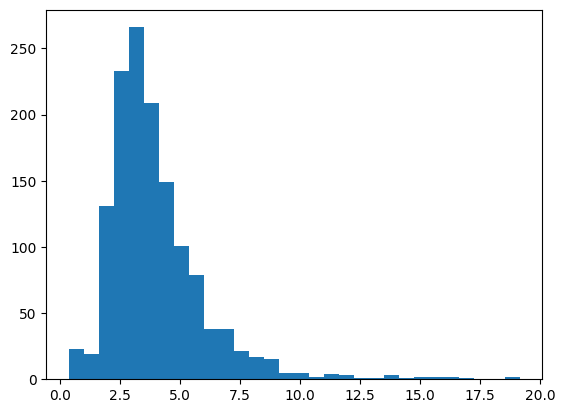

In [54]:
test_data_path = "/projects/vig/alberto/medical/deform-aneurysm-detection/labels/gt/internal_test_crop_0.4.csv"
df_test = pd.read_csv(test_data_path)
df_test = add_size_based_fields(df_test, spacing=0.4)
df_test["size"].value_counts()/len(df_test)


size
medium    0.714286
small     0.230159
large     0.055556
Name: count, dtype: float64

In [61]:
private_data_path = "/projects/vig/Datasets/aneurysm/cta_datasets/hospital140/annotations_aneurysm_extra.csv"
df_priv = pd.read_csv(private_data_path)
df_priv = add_size_based_fields(df_priv, spacing=0.4)
df_priv["size"].value_counts()/len(df_priv)

size
medium    0.566038
small     0.363208
large     0.070755
Name: count, dtype: float64

In [76]:
cmha_data_path ="/projects/vig/Datasets/aneurysm/cta_datasets/cmha/annotations.csv"
df_cmha = pd.read_csv(cmha_data_path)
df_cmha = add_size_based_fields(df_cmha, spacing=0.4)
df_cmha["size"].value_counts()/len(df_cmha)


size
medium    0.56
small     0.39
large     0.05
Name: count, dtype: float64

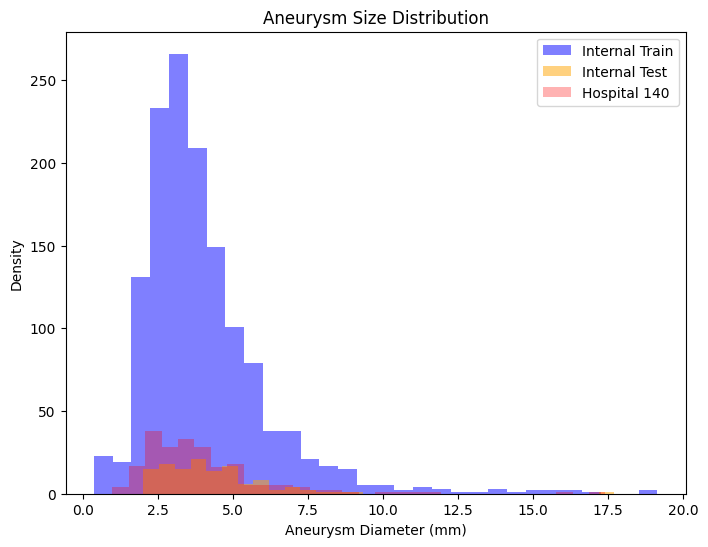

In [73]:
from cv2 import norm


sizes_train = df_train["diameter"].values
sizes_test = df_test["diameter"].values
sizes_priv = df_priv["diameter"].values
plt.figure(figsize=(8,6))
# plot discrete histograms

plt.hist(sizes_train, bins=30, alpha=0.5, label="Internal Train", color="blue")
plt.hist(sizes_test, bins=30,alpha=0.5, label="Internal Test", color="orange")
plt.hist(sizes_priv, bins=30,  alpha=0.3, label="Hospital 140", color="red")

plt.xlabel("Aneurysm Diameter (mm)")
plt.ylabel("Density")
plt.title("Aneurysm Size Distribution")
plt.legend()

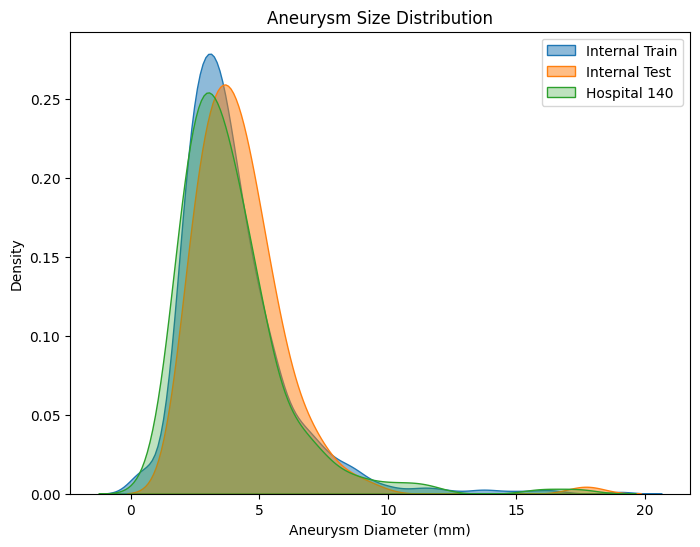

In [75]:
sizes_train = df_train["diameter"].values
sizes_test = df_test["diameter"].values
sizes_priv = df_priv["diameter"].values
plt.figure(figsize=(8,6))
# plot cumulative histograms 

sns.kdeplot(sizes_train, fill=True, alpha=0.5, label="Internal Train",  common_norm=False, )
sns.kdeplot(sizes_test, fill=True, alpha=0.5, label="Internal Test",  common_norm=False, )
sns.kdeplot(sizes_priv, fill=True, alpha=0.3, label="Hospital 140",  common_norm=False, )

plt.xlabel("Aneurysm Diameter (mm)")
plt.ylabel("Density")
plt.title("Aneurysm Size Distribution")
plt.legend()